In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
import requests
import pandas as pd
import json
import time
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import mean_absolute_percentage_error
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import seaborn as sns 

# for dirname, _, filenames in os.walk("./"):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# 1. Frame the problem
Using the customer description, Define the problem your trying to solve in your own words (remember this is not technial but must be specific so the customer understands the project

The customer needs an ML model to be able to identify cursive letter with a given picture. We must use the sample
images firstly by standardizing images and then uploading it into a csv in order to create a model with accurate results

# 2. Get the Data 
Define how you recieved the data (provided, gathered..)

In [2]:
# Given by teacher on a google drive and downloaded a zip file

In [49]:
import zipfile as zf
import os
# Make a folder of files
zip_name = 'Cursive-20251027T122349Z-1-001.zip'
try:
    with zf.ZipFile(zip_name, 'r') as files:
        files.extractall()
except:
    print("Unexpected error")

In [50]:
import pandas as pd
from pathlib import Path
import re 

ROOT_DIR = Path('/home/jupyter-259941/Machine-Learning-AI-Honors/Project_5/Cursive') 
GENERIC_PREFIXES = ('IMG_','2024') 

# *** NEW: Define the image formats you want to process ***
ALLOWED_FORMATS = {'.jpg', '.jpeg', '.png', '.heic', '.bmp', '.tiff'}

data_list = []

STUDENT_ID_PATTERN = re.compile(r'^[Ss]\d+$')

print("Phase 1: Collecting file metadata and checking labels (Handling new prefixes)...")

for file_path in ROOT_DIR.glob('**/*'):
    if file_path.is_file():
        
        # *** NEW: Check the file format *before* doing anything else ***
        file_format = file_path.suffix.lower()
        if file_format not in ALLOWED_FORMATS:
            continue # Skip this file completely (e.g., /S33/q, .DS_Store, etc.)
        
        # Student is ID 
        student_id = 'UNKNOWN'
        
        for parent in file_path.parents:
            if parent == ROOT_DIR:
                break 
            
            if STUDENT_ID_PATTERN.match(parent.name):
                student_id = parent.name
                break 

        letter_label = file_path.stem.strip()
        # file_format = file_path.suffix.lower() # <--- Already defined this above
        
        # --- Recommended Improvement (makes prefix check case-insensitive) ---
        is_generic = any(letter_label.lower().startswith(p.lower()) for p in GENERIC_PREFIXES)
        # --- End of improvement ---

        is_labeled = not is_generic and len(letter_label) == 1
        
        # Calculate the final path if the conversion were to happen in-place
        final_path_str = str(file_path.with_suffix('.png'))
        
        data_list.append({
            'original_path': str(file_path),
            'student_id': student_id,
            'label': letter_label if is_labeled else 'UNLABELED',
            'format': file_format,
            'status': 'READY' if is_labeled and student_id != 'UNKNOWN' else 'SKIP',
            'action': 'CONVERT_AND_DELETE' if file_format != '.png' and is_labeled else 'KEEP',
            'final_path': final_path_str
        })

df = pd.DataFrame(data_list)

print(f"Phase 1 Complete. Collected {len(df)} records. Check the 'file_inventory.csv' for the next step.")
df.to_csv('file_inventory.csv', index=False)

Phase 1: Collecting file metadata and checking labels (Handling new prefixes)...
Phase 1 Complete. Collected 1254 records. Check the 'file_inventory.csv' for the next step.


In [51]:
import pandas as pd
from PIL import Image
from pathlib import Path
from pillow_heif import register_heif_opener
import os
import concurrent.futures
from tqdm import tqdm  # For the progress bar
import time

# --- Worker Function ---
# This is the task that each parallel process will run.
def convert_and_delete(paths):
    """
    Converts a single image to PNG and deletes the original.
    
    Args:
        paths (tuple): A tuple containing (original_path_str, final_path_str)
        
    Returns:
        A tuple (status, original_path, message)
    """
    # CRITICAL: Each new process must register the opener
    register_heif_opener()
    
    original_path_str, final_path_str = paths
    original_path = Path(original_path_str)
    final_path = Path(final_path_str)
    TARGET_FORMAT = 'PNG'
    
    try:
        # 1. Convert
        img = Image.open(original_path)
        img.save(final_path, TARGET_FORMAT)
        
        # 2. Delete Original
        os.remove(original_path)
        
        return ("SUCCESS", original_path_str, None)

    except Exception as e:
        return ("ERROR", original_path_str, str(e))

# --- Main Script Logic ---
# We must wrap the main execution logic in this block
# This is a safety guard for multiprocessing.
if __name__ == "__main__":
    
    start_time = time.time()
    INPUT_CSV = 'file_inventory.csv'
    
    # Load the planning data
    print("Loading file inventory...")
    df_inventory = pd.read_csv(INPUT_CSV)

    # Filter for files that are ready and need conversion
    df_action = df_inventory[
        (df_inventory['status'] == 'READY') & 
        (df_inventory['format'] != '.png')
    ].copy()

    if df_action.empty:
        print("No non-PNG files found that require conversion. Done.")
    else:
        file_count = len(df_action)
        print(f"Phase 2: Starting parallel conversion for {file_count} files...")
        
        # 1. Create a list of tasks (tuples of paths)
        # This is much faster than iterrows()
        tasks = list(zip(df_action['original_path'], df_action['final_path']))
        
        deleted_count = 0
        failed_files = []

        # 2. This is the parallel processing part
        # ProcessPoolExecutor() automatically uses all your CPU cores
        with concurrent.futures.ProcessPoolExecutor() as executor:
            
            # 3. 'executor.map' runs the function on each item in 'tasks'
            # 'tqdm' wraps it to show a progress bar
            results = list(tqdm(
                executor.map(convert_and_delete, tasks), 
                total=file_count
            ))

        # 4. Tally the results after everything is done
        for status, path, message in results:
            if status == "SUCCESS":
                deleted_count += 1
            else:
                failed_files.append((path, message))

        end_time = time.time()
        print("\n--- Phase 2 Complete ---")
        print(f"Successfully converted and deleted {deleted_count} files.")
        
        if failed_files:
            print(f"\nFailed to process {len(failed_files)} files:")
            for path, error in failed_files:
                print(f"  - File: {path}\n    Error: {error}")
        
        print(f"\nTotal time taken: {end_time - start_time:.2f} seconds.")

Loading file inventory...
Phase 2: Starting parallel conversion for 357 files...


100%|██████████| 357/357 [00:24<00:00, 14.34it/s]



--- Phase 2 Complete ---
Successfully converted and deleted 357 files.

Total time taken: 30.07 seconds.


In [ ]:
from PIL import Image, ImageOps
import pandas as pd
from tqdm import tqdm
import os

# --- 1. Define the CropWhitespace function (standalone) ---
def crop_image(img_path):
    try:
        img = Image.open(img_path).convert('L') # Open as grayscale
        inverted_img = ImageOps.invert(img) # Invert so letter is white
        bbox = inverted_img.getbbox() # Get the bounding box
        
        if bbox:
            cropped_img = img.crop(bbox) # Crop the *original* image
            # Save the cropped image, overwriting the original
            cropped_img.save(img_path)
            return "SUCCESS"
        else:
            return "SKIPPED (No content)"
    except Exception as e:
        return f"ERROR: {e}"

# --- 2. Load your file inventory ---
df = pd.read_csv('file_inventory.csv')
df_ready = df[df['status'] == 'READY'].copy()

print(f"Found {len(df_ready)} 'READY' images in CSV. Verifying and cropping...")

# --- 3. Find *only* the good files and crop them ---
good_files_to_crop = []
for path in df_ready['final_path']:
    if os.path.exists(path):
        good_files_to_crop.append(path)

print(f"Found {len(good_files_to_crop)} images on disk. Cropping them now...")

# --- 4. Run the cropping process (this is the one-time operation) ---
for path in tqdm(good_files_to_crop):
    crop_image(path)

print("--- Pre-processing Complete ---")
print(f"All {len(good_files_to_crop)} custom images are now permanently cropped.")

In [52]:
import string

# Our 'source of truth' map: {'A': 0, 'B': 1, ..., 'Z': 25}
# We will make all our labels (from your CSV and from EMNIST) follow this.
SIMPLE_LETTER_MAP = {letter: index for index, letter in enumerate(string.ascii_uppercase)}

print(SIMPLE_LETTER_MAP)
# Output: {'A': 0, 'B': 1, 'C': 2, ..., 'Z': 25}

{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25}


In [66]:
import os
import pandas as pd
from torch.utils.data import Dataset
from PIL import Image
import torch

class CursiveDataset(Dataset):
    def __init__(self, csv_path, letter_map, transform=None):
        self.transform = transform
        self.letter_map = letter_map

        df = pd.read_csv(csv_path)
        df_ready = df[df['status'] == 'READY'].copy()
        
        print("CursiveDataset: Verifying image files...")
        self.image_paths = []
        self.char_labels = []
        
        total_ready = len(df_ready)
        for idx, row in df_ready.iterrows():
            path = row['final_path']
            
            # Check if the file exists on disk
            if os.path.exists(path):
                self.image_paths.append(path)
                self.char_labels.append(row['label'])
        
        found_images = len(self.image_paths)
        skipped_count = total_ready - found_images
        print(f"CursiveDataset: Found {found_images} valid images.")
        print(f"CursiveDataset: Skipped {skipped_count} missing files (from S28/S29).")
        # --- END OF FIX ---

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # 1. Get the path and string label
        img_path = self.image_paths[idx]
        char_label = self.char_labels[idx]
        
        # 2. Load the image
        # We don't need a try/except, we know the file exists
        image = Image.open(img_path).convert('L') 
        
        # 3. Convert the string label ('s') to the numeric label (18)
        try:
            numeric_label = self.letter_map[char_label.upper()]
        except KeyError:
            print(f"Error: Label '{char_label}' is not a valid letter (A-Z)!")
            numeric_label = 0 # Fallback
            
        # 4. Apply the shared transform
        if self.transform:
            image = self.transform(image)
            
        return image, numeric_label

In [67]:
import torchvision.transforms as transforms
from torchvision.datasets import EMNIST
from torch.utils.data import ConcatDataset, DataLoader

# Define the ONE transform that both datasets will use
# Using standard MNIST mean/std is a safe bet
mean, std = (0.1307,), (0.3081,) 

main_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# 1. Load EMNIST 'letters' dataset
emnist_train_dataset = EMNIST(
    root='./data',
    split='letters',
    train=True,
    download=True,
    transform=main_transform,
    # THIS IS CRITICAL:
    # EMNIST labels are 1-26. This lambda makes them 0-25.
    target_transform=lambda y: y - 1 
)

# 2. Load your custom 800-image dataset
custom_train_dataset = CursiveDataset(
    csv_path='file_inventory.csv',
    letter_map=SIMPLE_LETTER_MAP, # Pass in our new map
    transform=main_transform      # Use the *exact same* transform
)

# 3. Combine them!
combined_dataset = ConcatDataset([emnist_train_dataset, custom_train_dataset])

print(f"--- Dataset Report ---")
print(f"EMNIST 'letters' images: {len(emnist_train_dataset)}")
print(f"Custom 'letters' images: {len(custom_train_dataset)}")
print(f"TOTAL images:            {len(combined_dataset)}")

# 4. Create your final DataLoader
final_train_loader = DataLoader(
    combined_dataset,
    batch_size=64,
    shuffle=True
)

CursiveDataset: Verifying image files...
CursiveDataset: Found 857 valid images.
CursiveDataset: Skipped 52 missing files (from S28/S29).
--- Dataset Report ---
EMNIST 'letters' images: 124800
Custom 'letters' images: 857
TOTAL images:            125657


# 3. Explore the Data
Gain insights into the data you have from step 2, making sure to identify any bias

In [68]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision.utils
# ^^^ You must import your loader and map from your other script

# --- Helper function to show a grid of images ---
def imshow_batch(img_tensor, labels, reverse_map):
    # 1. Un-normalize the images
    # We need to reverse the (img - mean) / std operation
    grid = torchvision.utils.make_grid(img_tensor, nrow=8) # 8 images per row
    grid = grid * std[0] + mean[0] # Reverse normalization
    grid = np.clip(grid, 0, 1)     # Clip values to be between 0 and 1
    
    # 2. Convert to format for plotting
    plt_img = np.transpose(grid.numpy(), (1, 2, 0))
    
    # 3. Create the plot
    plt.figure(figsize=(12, 6))
    plt.imshow(plt_img)
    
    # 4. Create the title with all labels
    label_strings = [reverse_map.get(label.item(), '??') for label in labels]
    title = "Batch Labels:\n" + ", ".join(label_strings)
    plt.title(title)
    plt.axis('off')
    plt.show()

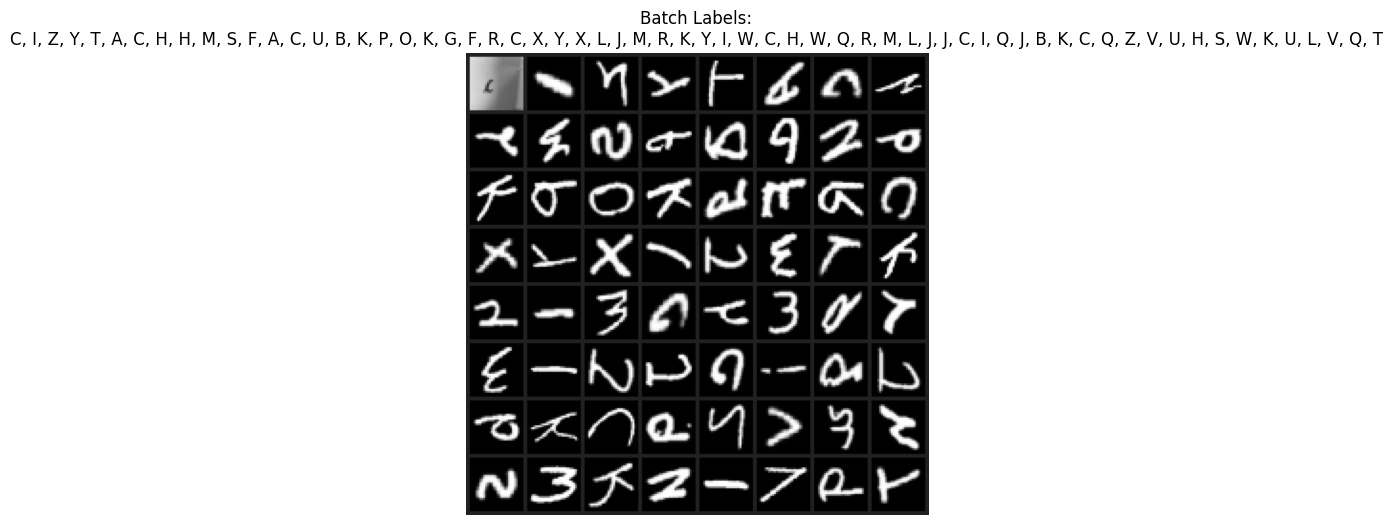

In [69]:
# --- Create the Reverse Map to see letters ---
# Goes from index to letter, e.g., {0: 'A', 1: 'B', ...}
REVERSE_LETTER_MAP = {index: letter for letter, index in SIMPLE_LETTER_MAP.items()}

# --- Get one batch of data ---
data_iter = iter(final_train_loader)
images, labels = next(data_iter)

# --- Show the images and labels ---
imshow_batch(images, labels, REVERSE_LETTER_MAP)

General Insight:

S folders sometimes have subfolders, Different folders are not in order, Some folders are empty
Use regex to clean it up and properly code to handle subfolders

Bias: Assume all data are labeled correctly (a.png is a picture of the letter a not b)

--- EMNIST Image (Index 0) ---


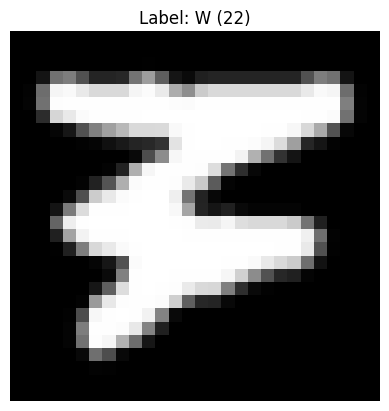

--- Your First Custom Image (Index 124800) ---


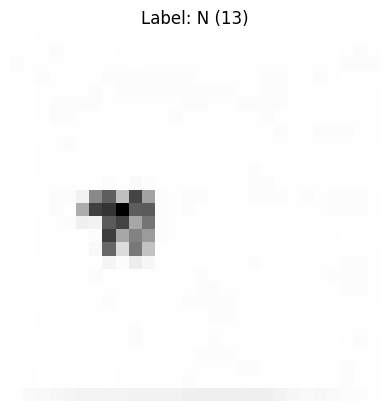

In [70]:
def imshow_single(img_tensor, label_idx, reverse_map):
    # 1. Un-normalize
    img = img_tensor * std[0] + mean[0]
    img = np.clip(img.numpy(), 0, 1)
    
    # 2. Squeeze to remove color channel for plotting
    plt.imshow(img.squeeze(), cmap="gray")
    
    # 3. Get label string
    label = reverse_map.get(label_idx, "??")
    plt.title(f"Label: {label} ({label_idx})")
    plt.axis('off')
    plt.show()

# --- 1. Check a standard EMNIST image (the first one) ---
img_emnist, label_emnist = combined_dataset[0]
print("--- EMNIST Image (Index 0) ---")
imshow_single(img_emnist, label_emnist, REVERSE_LETTER_MAP)


# --- 2. Check your FIRST custom image ---
first_custom_index = len(emnist_train_dataset)
img_custom, label_custom = combined_dataset[first_custom_index]
print(f"--- Your First Custom Image (Index {first_custom_index}) ---")
imshow_single(img_custom, label_custom, REVERSE_LETTER_MAP)

# 4.Prepare the Data


Apply any data transformations and explain what and why


In [ ]:
# The EMNIST letters are different, inversed colors and whitespace

In [72]:
from PIL import Image, ImageOps
import torchvision.transforms as transforms
import numpy as np

# Define a custom transform to crop whitespace (assume black letter on white background)
class CropWhitespace:
    def __call__(self, img):
        try:
            # Convert to 'L' (grayscale) and invert
            inverted_img = ImageOps.invert(img.convert('L'))
            bbox = inverted_img.getbbox()
            
            if bbox:
                return img.crop(bbox)
            else:
                return img
        except Exception as e:
            print(f"Warning: CropWhitespace failed. Returning original image. Error: {e}")
            return img

In [73]:
custom_transform_v3 = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # PIL
    
    CropWhitespace(),                           # PIL: Crop to letter
    
    transforms.Resize((28, 28)),                # PIL: Resize *only* the letter
    transforms.ToTensor(),                      # PIL -> Tensor
    
    transforms.RandomInvert(p=1.0),             # Tensor: Invert to match EMNIST
    
    transforms.Normalize(mean, std)             # Tensor
])

print("Defined 'custom_transform_v3' with cropping and inversion.")


Defined 'custom_transform_v3' with cropping and inversion.


In [74]:
final_combined_dataset = ConcatDataset([emnist_train_dataset, custom_dataset_v3])

final_train_loader = DataLoader(
    final_combined_dataset,
    batch_size=64,
    shuffle=True
)

print("Created 'final_train_loader' (using the correctly named 'emnist_train_dataset').")

Created 'final_train_loader' (using the correctly named 'emnist_train_dataset').


--- EMNIST Image (Index 0) ---


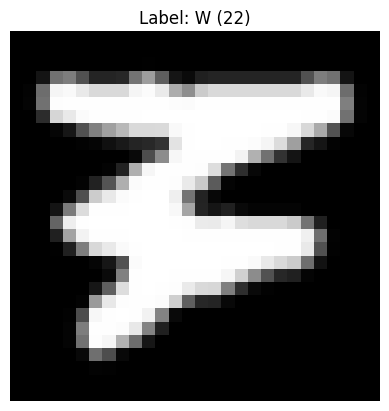

--- Your First Custom Image (Index 124800) ---


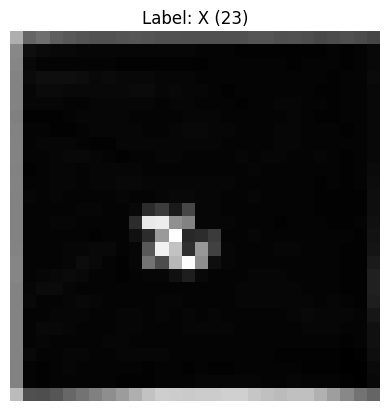

In [75]:
# (Your imshow_single function)
def imshow_single(img_tensor, label_idx, reverse_map):
    # 1. Un-normalize
    img = img_tensor * std[0] + mean[0]
    img = np.clip(img.numpy(), 0, 1)
    
    # 2. Squeeze to remove color channel for plotting
    plt.imshow(img.squeeze(), cmap="gray")
    
    # 3. Get label string
    label = reverse_map.get(label_idx, "??")
    plt.title(f"Label: {label} ({label_idx})")
    plt.axis('off')
    plt.show()

# --- 1. Check a standard EMNIST image ---
img_emnist, label_emnist = final_combined_dataset[0]
print("--- EMNIST Image (Index 0) ---")
imshow_single(img_emnist, label_emnist, REVERSE_LETTER_MAP)


# --- 2. Check your FIRST custom image ---
first_custom_index = len(emnist_train_dataset)
# --- FIX: Use 'final_combined_dataset' to see the v3-transformed image ---
img_custom, label_custom = final_combined_dataset[first_custom_index] 
print(f"--- Your First Custom Image (Index {first_custom_index}) ---")
imshow_single(img_custom, label_custom, REVERSE_LETTER_MAP)

In [76]:
emnist_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# 2. Create the EMNIST test dataset
test_dataset = EMNIST(
    root='./data',
    split='letters',
    train=False,
    download=True,
    transform=emnist_transform,
    target_transform=lambda y: y - 1  # Still need to map 1-26 -> 0-25
)

# 3. Create the final test_loader
test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=4
)

print(f"\n--- Test Set Ready ---")
print(f"Total test images: {len(test_dataset)}")


--- Test Set Ready ---
Total test images: 20800


# 5. Model the data
Using selected ML models, experment with your choices and describe your findings. Finish by selecting a Model to continue with


In [92]:
import os
import pandas as pd
from torch.utils.data import Dataset
from PIL import Image
import torch
import torchvision.transforms as transforms
print("--- FORCE OVERWRITE CELL ---")
print("Defining the CursiveDataset class")

class CursiveDataset(Dataset):
    def __init__(self, csv_path, letter_map, transform=None):
        self.transform = transform
        self.letter_map = letter_map
        df = pd.read_csv(csv_path)
        df_ready = df[df['status'] == 'READY'].copy()
        
        print("CursiveDataset: Verifying image files...")
        self.image_paths = []
        self.char_labels = []
        total_ready = len(df_ready)
        
        for idx, row in df_ready.iterrows():
            path = row['final_path']
            if os.path.exists(path):
                self.image_paths.append(path)
                self.char_labels.append(row['label'])
        
        found_images = len(self.image_paths)
        skipped_count = total_ready - found_images
        print(f"CursiveDataset: Found {found_images} valid images.")
        if skipped_count > 0:
            print(f"CursiveDataset: Skipped {skipped_count} missing files.")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        char_label = self.char_labels[idx]
        image = Image.open(img_path).convert('L') 
        
        try:
            numeric_label = self.letter_map[char_label.upper()]
        except KeyError:
            numeric_label = 0 # Fallback
            
        if self.transform:
            image = self.transform(image)
        return image, numeric_label


print("Re-creating custom dataset...")
custom_dataset_v3 = CursiveDataset(
    csv_path='file_inventory.csv',
    letter_map=SIMPLE_LETTER_MAP,
    transform=custom_transform_v3
)

print("Re-creating combined dataset and loader...")
final_combined_dataset = ConcatDataset([emnist_train_dataset, custom_dataset_v3])

final_train_loader = DataLoader(
    final_combined_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=os.cpu_count()
)

print("--- READY TO TRAIN. All objects are now correct. ---")

--- FORCE OVERWRITE CELL ---
Defining the CursiveDataset class
Re-creating custom dataset...
CursiveDataset: Verifying image files...
CursiveDataset: Found 857 valid images.
CursiveDataset: Skipped 52 missing files.
Re-creating combined dataset and loader...
--- READY TO TRAIN. All objects are now correct. ---


In [82]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 5) 
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        
        self.fc1 = nn.Linear(16 * 4 * 4, 120) 
        self.fc2 = nn.Linear(120, 84)
        
        self.fc3 = nn.Linear(84, 26)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = SimpleCNN()
print("Created corrected model.")

Created corrected model.


In [83]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss(ignore_index=-1)
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [84]:
for epoch in range(2):
    running_loss = 0.0
    
    # Loop over the final_train_loader
    for i, data in enumerate(final_train_loader, 0):
        inputs, labels = data
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if i % 1000 == 999: # Print every 1000 batches
            print(f'[Epoch: {epoch + 1}, Batch: {i + 1}] loss: {running_loss / 1000:.3f}')
            running_loss = 0.0


[Epoch: 1, Batch: 1000] loss: 2.896
[Epoch: 2, Batch: 1000] loss: 0.669


In [85]:
correct = 0
total = 0

with torch.no_grad():
    for data in test_loader: 
        images, labels = data
        
        # Calculate model outputs
        outputs = net(images)
        
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'--- Test Results ---')
print(f'Accuracy on test images: {accuracy:.2f} %')

--- Test Results ---
Accuracy on test images: 84.25 %


# 6. Fine Tune the Model

With the select model descibe the steps taken to acheve the best rusults possiable 


In [88]:
criterion = nn.CrossEntropyLoss(ignore_index=-1)
optimizer = optim.Adam(net.parameters(), lr=0.001)

In [93]:
for epoch in range(10):
    running_loss = 0.0
    
    # Loop over the final_train_loader
    for i, data in enumerate(final_train_loader, 0):
        inputs, labels = data
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if i % 1000 == 999: # Print every 1000 batches
            print(f'[Epoch: {epoch + 1}, Batch: {i + 1}] loss: {running_loss / 1000:.3f}')
            running_loss = 0.0
print("Finish Training")

[Epoch: 1, Batch: 1000] loss: 0.176
[Epoch: 2, Batch: 1000] loss: 0.164
[Epoch: 3, Batch: 1000] loss: 0.155
[Epoch: 4, Batch: 1000] loss: 0.147
[Epoch: 5, Batch: 1000] loss: 0.140
[Epoch: 6, Batch: 1000] loss: 0.138
[Epoch: 7, Batch: 1000] loss: 0.129
[Epoch: 8, Batch: 1000] loss: 0.129
[Epoch: 9, Batch: 1000] loss: 0.121
[Epoch: 10, Batch: 1000] loss: 0.119
Finish Training


In [94]:
correct = 0
total = 0

with torch.no_grad():
    for data in test_loader: 
        images, labels = data
        outputs = net(images)
        
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'--- Test Results ---')
print(f'Accuracy on test images: {accuracy:.2f} %')

--- Test Results ---
Accuracy on test images: 92.76 %


In [95]:
torch.save(net.state_dict(), 'CNN_model.pth')

While High Accuracy, implementation into inference function shows that this is a result of overpowering of EMNIST data to the
cursive data. Plan to decreast EMNIST size and expect lower but honest accuracy

In [130]:
import torch
from torch.utils.data import Subset

print("--- Subsetting EMNIST ---")


num_custom_images = 857 
num_emnist_images = num_custom_images * 2  # This is your 1714
print(f"Subsetting EMNIST to {num_emnist_images} random images.")


total_emnist_size = len(emnist_train_dataset)


indices = torch.randperm(total_emnist_size)
emnist_indices_subset = indices[:num_emnist_images]


emnist_subset = Subset(emnist_train_dataset, emnist_indices_subset)

print(f"Created EMNIST subset with {len(emnist_subset)} images.")

--- Fix 3: Subsetting EMNIST ---
Subsetting EMNIST to 1714 random images.
Created EMNIST subset with 1714 images.


In [133]:
final_combined_dataset_subset = ConcatDataset([emnist_subset, custom_dataset_v3])


final_train_loader = DataLoader(
    final_combined_dataset_subset,
    batch_size=32,
    shuffle=True,  
    num_workers=0
)

print(f"--- Ready to Train (Fast) ---")
print(f"Total training images: {len(final_combined_dataset_subset)}")

--- Ready to Train (Fast) ---
Total training images: 2571


In [137]:
for epoch in range(3):
    running_loss = 0.0
    for i, data in enumerate(final_train_loader, 0):
        inputs, labels = data
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if i % 40 == 39:
            print(f'[Epoch: {epoch + 1}, Batch: {i + 1}] loss: {running_loss / 1000:.3f}')
            running_loss = 0.0
print("Finish Training")

[Epoch: 1, Batch: 40] loss: 0.002
[Epoch: 1, Batch: 80] loss: 0.002
[Epoch: 2, Batch: 40] loss: 0.001
[Epoch: 2, Batch: 80] loss: 0.002
[Epoch: 3, Batch: 40] loss: 0.001
[Epoch: 3, Batch: 80] loss: 0.001
Finish Training


In [138]:
test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=4
)

In [139]:
correct = 0
total = 0

with torch.no_grad():
    for data in test_loader: 
        images, labels = data
        outputs = net(images)
        
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'--- Test Results ---')
print(f'Accuracy on test images: {accuracy:.2f} %')

--- Test Results ---
Accuracy on test images: 91.15 %


In [140]:
torch.save(net.state_dict(), 'CNN_model.pth')

Whiie this has lower accuracy, it payed more attention to the cursive images, resulting in better results for inference fucntion

# 7. Present
In a customer faceing Document provide summery of finding and detail approach taken


First, we noticed the data given was very messy and hard to work with, from duplicates, less pictures, empty folders, and
folders with subfolders. I used regex to be able to access all photos in the system. Then I decided to use both EMNIST dataset
from pytorch. I used a very simple CNN model to train and started off with 2 epochs and 84 percent accuracy. I let it run for about 10 more and got it to a 95. However, when I tried to use my handwriting, it failed. I tried with other handwritings of filtered out images and they also weren't successful. I then used a smaller dataset which was riskier by implementing less EMNIST images. It reduced accuracy to 91 but it resulted in a much better output. 

# 8. Launch the Model System
Define your production run code, This should be self susficent and require only your model pramaters 


In [141]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image, ImageOps
import string
import numpy as np
import os

def inference(image_path):
    
    # --- 1. Check if files exist ---
    if not os.path.exists(image_path):
        return f"Error: Image file not found at {image_path}"

    # --- 2. Define Model Architecture ---
    class SimpleCNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.conv1 = nn.Conv2d(1, 6, 5) 
            self.pool = nn.MaxPool2d(2, 2)
            self.conv2 = nn.Conv2d(6, 16, 5)
            self.fc1 = nn.Linear(16 * 4 * 4, 120) 
            self.fc2 = nn.Linear(120, 84)
            self.fc3 = nn.Linear(84, 26)

        def forward(self, x):
            x = self.pool(F.relu(self.conv1(x)))
            x = self.pool(F.relu(self.conv2(x)))
            x = torch.flatten(x, 1)
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            x = self.fc3(x)
            return x

    # --- 3. Define Custom Transform ---
    class CropWhitespace:
        def __call__(self, img):
            try:
                inverted_img = ImageOps.invert(img.convert('L'))
                bbox = inverted_img.getbbox()
                if bbox:
                    return img.crop(bbox)
                else: return img
            except Exception as e:
                return img

    # --- 4. Define Transforms & Maps ---
    mean, std = (0.1307,), (0.3081,)
    inference_transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        CropWhitespace(),
        transforms.Resize((28, 28), interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.ToTensor(),
        transforms.RandomInvert(p=1.0),
        transforms.Normalize(mean, std)
    ])
    REVERSE_LETTER_MAP = {
        0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 9: 'J', 10: 'K', 11: 'L', 12: 'M', 13: 'N', 14: 'O', 
        15: 'P', 16: 'Q', 17: 'R', 18: 'S', 19: 'T', 20: 'U', 21: 'V', 22: 'W', 23: 'X', 24: 'Y', 25: 'Z'
    }

    # --- 5. Load Model (Inefficient, but self-contained) ---
    model = SimpleCNN()
    model.load_state_dict(torch.load('CNN_model.pth'))
    model.eval()

    # --- 6. Load and Process Image ---
    try:
        image = Image.open(image_path)
        img_tensor = inference_transform(image).unsqueeze(0) # Add batch dim
    except Exception as e:
        return f"Error processing image: {e}"

    # --- 7. Make Prediction ---
    with torch.no_grad():
        output = model(img_tensor)
        
    pred_index = output.argmax(1).item()
    letter = REVERSE_LETTER_MAP.get(pred_index, "??")
    
    return letter

In [163]:
print(inference("/home/jupyter-259941/Machine-Learning-AI-Honors/Project_5/IMG_4866.jpg"))

A
